In [1]:
import os
import sys

root = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm"

if root not in sys.path:
    sys.path.append(root)

import torch
import re
import csv
import random
import numpy as np
import pandas as pd
import yaml
import json
from argparse import ArgumentParser
from torch.utils.data import DataLoader
from tqdm import tqdm
import pdb
from dataset.cifar10 import CIFAR10Dataset
from dataset.cifar20 import CIFAR20Dataset, CIFAR100Dataset
from dataset.tiny200 import Tiny200Dataset
from dataset.caltech101 import Caltech101Dataset

from models.llava_classifier import LLaVAClassifier
from models.qwen_classifier import QWENClassifier
from models.clip_model import CLIPModel
from PIL import Image   

/tmp2/maitanha/vgu/cll_vlm/venv_cll_qwen/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version is above 3.10, patching the collections module.


/tmp2/maitanha/vgu/cll_vlm/venv_cll_qwen/lib/python3.13/site-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


In [ ]:
def load_config(config_path):
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file '{config_path}' not found.")
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config

def collate_fn(batch):
    images, labels = zip(*batch)
    return list(images), list(labels)

def load_dataset(data_name):
    BASE_DIR = "/tmp2/maitanha/vgu/cll_vlm"
    DATA_DIR = os.path.join(BASE_DIR, "cll_vlm/data")

    data_root_path = os.path.join(DATA_DIR, data_name)

    if data_name == "cifar10":
        dataset = CIFAR10Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    elif data_name == "cifar20":
        dataset = CIFAR20Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    elif data_name == "cifar100":
        dataset = CIFAR100Dataset(
            root = data_root_path,
            train=True,
            transform=None
        )
        fine_classes_raw = dataset.get_fine_classes()
        fine_classes = [
            CIFAR100Dataset.preprocess_label(lbl)
            for lbl in fine_classes_raw
        ]
        coarse_classes = dataset.get_coarse_classes()
    elif data_name == "tiny200":
        dataset = Tiny200Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    elif data_name == "caltech-101":
        dataset = Caltech101Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    else:
        raise ValueError(f"Dataset '{data_name}' chưa được hỗ trợ trong hàm load_dataset.")
    
    return dataset

In [3]:
dataset = load_dataset("caltech-101")
fine_classes_raw = dataset.classes
fine_classes = [
    dataset.preprocess_label(lbl)
    for lbl in fine_classes_raw
]

print(fine_classes)

original_dataset, shuffled_dataset = dataset.get_shuffled_labels_dataset(seed=42)

['faces', 'faces easy', 'leopards', 'motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car side', 'ceiling fan', 'cellphone', 'chair', 'chandelier', 'cougar body', 'cougar face', 'crab', 'crayfish', 'crocodile', 'crocodile head', 'cup', 'dalmatian', 'dollar bill', 'dolphin', 'dragonfly', 'electric guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo head', 'garfield', 'gerenuk', 'gramophone', 'grand piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline skate', 'joshua tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea horse', 'snoopy', 'soccer ball', 'stapler

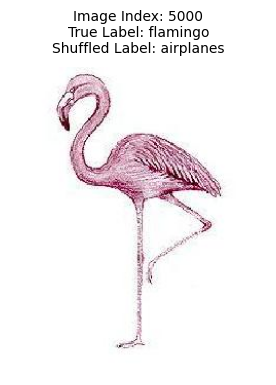

In [4]:
import matplotlib.pyplot as plt

def display_image(data, fine_classes, true_label_idx, shuffled_label_idx, img_idx):

    image, _ = data[img_idx]
    
    true_label = fine_classes[true_label_idx]
    shuffled_label = fine_classes[shuffled_label_idx]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    
    title_text = f"Image Index: {img_idx}\n"
    title_text += f"True Label: {true_label}\n"
    title_text += f"Shuffled Label: {shuffled_label}"
    
    plt.title(title_text, fontsize=10, pad=10)
    plt.axis('off')
    plt.show()

img_idx = 5000

_, true_label_idx = original_dataset[img_idx]
_, shuffled_label_idx = shuffled_dataset[img_idx]

display_image(shuffled_dataset, fine_classes, true_label_idx, shuffled_label_idx, img_idx)

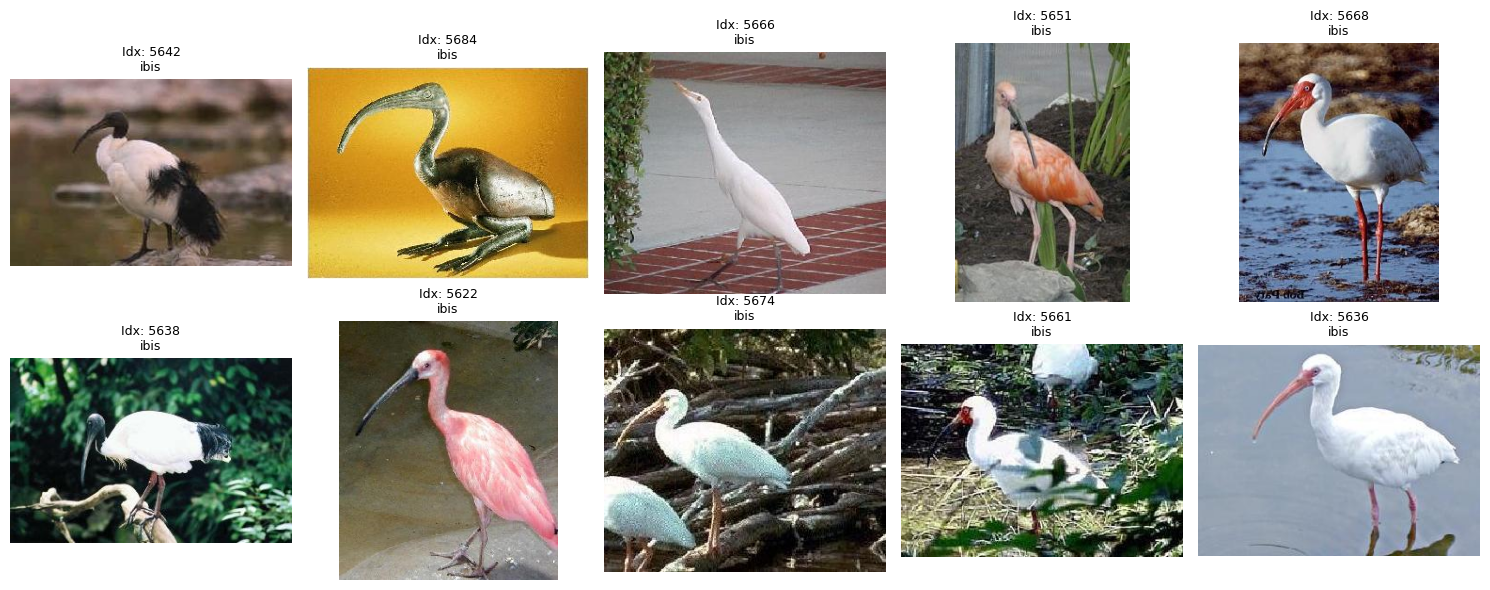

In [5]:
def display_samples_by_label(data, label_name, num_images=5):
    """
    Hiển thị ngẫu nhiên các ảnh từ dataset dựa trên tên label (không phân biệt hoa thường).
    """
    label_idx = -1
    processed_label = label_name.lower().replace("_", " ")
    
    # Tìm index dựa trên danh sách fine_classes đã có trong notebook
    if processed_label in fine_classes:
        label_idx = fine_classes.index(processed_label)
    elif label_name in dataset.classes:
        label_idx = dataset.classes.index(label_name)
    
    if label_idx == -1:
        print(f"Lỗi: Không tìm thấy label {label_name} trong dataset.")
        return

    # Lọc các indices có nhãn này
    indices = [i for i, target in enumerate(dataset.targets) if target == label_idx]
    
    if not indices:
        print(f"Không tìm thấy ảnh nào cho nhãn: {label_name}")
        return
    
    # Chọn ngẫu nhiên
    n = min(num_images, len(indices))
    selected_indices = random.sample(indices, n)
    
    # Hiển thị
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, idx in enumerate(selected_indices):
        image, _ = data[idx]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(f"Idx: {idx}\n{fine_classes[label_idx]}", fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Ví dụ sử dụng:
display_samples_by_label(original_dataset, "ibis", num_images=10)
